# Comprehensive Statistical Analysis for Tumor Microenvironment Study

This script performs rigorous case-level statistical analysis comparing:
- TMB-H (Microsatellite High Tumor Mutational Burden)
- MSS/TMB-L (Microsatellite Stable Low Tumor Mutational Burden)  
- MSI-H (Microsatellite Instability - High)

### The Scripts has the following Chaptes
1. [Load and Prepare Data](##Load-and-Prepare-Data)
2. [Case-Level Aggregation](##case-level-aggregation)
3. [Descriptive Statistics by Group](##Descriptive-Statistics-by-Group)
4. [Normality and Variance Tests](##Normality-and-Variance-Tests)
5. [Primary Statistical Tests](##Primary-Statistical-Tests)
6. [Visualization](##Visualization)
7. [Correlation Analysis](##Correlation-Analysis)
8. [Logistic Regression Analysis](##Logistic-Regression-Analysis)
9. [Machine Learning Classification](##Machine-Learning-Classification)
10. [Summary and Conclusions](##Summary-and-Conclusions)

In [2]:
# Import packages 
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    kruskal, mannwhitneyu, shapiro, gaussian_kde
)
from statannotations.Annotator import Annotator

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14

# Colors for consistency
GROUP_COLORS = {
    'MSS/TMB-H': '#E74C3C',
    'MSS/TMB-L': '#3498DB', 
    'MSI-H': '#2ECC71'
}

SUBTYPES = ['MSS/TMB-H', 'MSS/TMB-L', 'MSI-H']

## Load and Prepare Data

In [3]:
df = pd.read_csv('/cfs/earth/scratch/visciric/tumor-segmentation-ucec-stad/data/processed_csv/combined_wsi_data.csv')

print(f"\nRaw data loaded:")
print(f"  Total tiles: {len(df):,}")
print(f"  Total cases: {df['case_id'].nunique()}")
print(f"  Groups: {df['group'].unique()}")


Raw data loaded:
  Total tiles: 2,833,788
  Total cases: 514
  Groups: ['MSS/TMB-H' 'MSS/TMB-L' 'MSI-H']


In [4]:
# Define features of interest
cell_type_pcts = ['neoplastic_pct', 'inflammatory_pct', 'connective_pct', 
                   'necrosis_pct', 'non_neoplastic_pct']
cell_type_counts = ['neoplastic', 'inflammatory', 'connective', 
                     'necrosis', 'non_neoplastic', 'nolabel']
cell_type_normalized = ['neoplastic_normalized', 'inflammatory_normalized', 
                        'connective_normalized', 'necrosis_normalized']

## Case-Level Aggregation

In [5]:
# Aggregate to case level with multiple statistics
agg_dict = {
    'tile_id': 'count',
    'total_nuclei': ['sum', 'mean', 'std'],
    'total_normalized': ['mean', 'std'],
}

# Add cell type percentages
for col in cell_type_pcts:
    agg_dict[col] = ['mean', 'std']

# Add cell type counts
for col in cell_type_counts:
    agg_dict[col] = ['sum', 'mean']

# Add normalized
for col in cell_type_normalized:
    agg_dict[col] = ['mean', 'std']

# Perform aggregation
case_level = df.groupby(['case_id', 'group']).agg(agg_dict).reset_index()

# Flatten multi-level columns
case_level.columns = ['_'.join(col).strip('_') if col[1] else col[0] 
                       for col in case_level.columns.values]
case_level.rename(columns={'tile_id_count': 'n_tiles'}, inplace=True)

print(f"\nCase-level data created:")
print(f"  Total cases: {len(case_level)}")
for group in case_level['group'].unique():
    n = len(case_level[case_level['group'] == group])
    print(f"  {group}: {n} cases")


Case-level data created:
  Total cases: 514
  MSS/TMB-L: 320 cases
  MSI-H: 163 cases
  MSS/TMB-H: 31 cases


In [6]:
output_path = '../../data/processed_csv/case_level_aggregated.csv'
case_level.to_csv(output_path, index=False)

## Descriptive Statistics by Group

Characterize the distribution of immune metrics across molecular subtypes before formal testing.


**Why Median and IQR?**
- Biological data is often non-normally distributed
- Median is robust to outliers
- IQR (25th-75th percentile) shows spread without being affected by extreme values


In [7]:
key_metrics = [
    ('total_nuclei_sum', 'Total Nuclei per Case'),
    ('total_nuclei_mean', 'Mean Nuclei per Tile'),
    ('total_normalized_mean', 'Mean Cell normalized'),
    ('neoplastic_pct_mean', 'Neoplastic %'),
    ('inflammatory_pct_mean', 'Inflammatory %'),
    ('connective_pct_mean', 'Connective %'),
    ('necrosis_pct_mean', 'Necrosis %'),
    ('inflammatory_normalized_mean', 'Inflammatory Normalized'),
]

In [8]:
summary_stats = []
for metric, label in key_metrics:
    for group in SUBTYPES:
        data = case_level[case_level['group'] == group][metric].dropna()
        
        stats_dict = {
            'Metric': label,
            'Group': group,
            'N': len(data),
            'Mean': f"{data.mean():.2f}",
            'SD': f"{data.std():.2f}",
            'Median': f"{data.median():.2f}",
            'Q1': f"{data.quantile(0.25):.2f}",
            'Q3': f"{data.quantile(0.75):.2f}",
            'Min': f"{data.min():.2f}",
            'Max': f"{data.max():.2f}"
        }
        summary_stats.append(stats_dict)

summary_df = pd.DataFrame(summary_stats)

In [9]:
for group in SUBTYPES:
    df_group = summary_df[summary_df['Group'] == group].drop('Group', axis=1).reset_index(drop=True)
    
    display(df_group.style
            .set_caption(f"Summary Statistics - {group}")
            .set_properties(**{'text-align': 'center'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
                {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
            ]))

,Metric,N,Mean,SD,Median,Q1,Q3,Min,Max
0,Total Nuclei per Case,31,1746219.68,1134966.42,1523210.00,1015491.50,2218308.50,233947.00,4712994.00
1,Mean Nuclei per Tile,31,327.00,110.93,317.59,244.47,414.14,150.25,526.38
2,Mean Cell normalized,31,1030.76,3924.08,326.18,250.14,414.14,155.48,22167.43
3,Neoplastic %,31,38.27,23.07,36.15,22.03,44.23,1.95,87.75
4,Inflammatory %,31,11.72,5.13,9.87,8.32,15.60,4.97,25.57
5,Connective %,31,44.34,21.76,49.85,29.97,58.86,2.57,78.27
6,Necrosis %,31,3.37,3.09,2.36,1.48,4.69,0.34,14.57
7,Inflammatory Normalized,31,89.84,281.78,34.49,18.77,53.81,12.04,1602.25


,Metric,N,Mean,SD,Median,Q1,Q3,Min,Max
0,Total Nuclei per Case,320,1791141.76,898618.78,1816008.50,1191330.00,2434999.75,76224.00,4207530.00
1,Mean Nuclei per Tile,320,361.87,232.53,308.17,252.67,379.03,43.43,1404.26
2,Mean Cell normalized,320,362.00,232.86,308.21,252.70,379.03,43.43,1411.25
3,Neoplastic %,320,33.62,20.85,29.51,16.59,46.79,0.85,86.93
4,Inflammatory %,320,10.55,6.41,8.96,6.17,13.30,1.74,48.50
5,Connective %,320,50.75,20.44,53.63,37.64,65.88,5.86,90.30
6,Necrosis %,320,1.15,1.44,0.68,0.31,1.45,0.03,10.55
7,Inflammatory Normalized,320,45.18,50.08,29.55,16.34,51.76,1.55,421.90


,Metric,N,Mean,SD,Median,Q1,Q3,Min,Max
0,Total Nuclei per Case,163,1878991.09,1051310.38,1905699.00,1160998.50,2487292.50,132736.00,5413677.00
1,Mean Nuclei per Tile,163,382.86,224.69,347.35,262.72,412.27,110.63,1567.05
2,Mean Cell normalized,163,389.37,229.26,350.66,269.49,415.56,114.23,1567.09
3,Neoplastic %,163,35.47,20.66,33.51,21.14,45.08,2.13,93.59
4,Inflammatory %,163,12.30,6.21,12.04,7.31,16.17,1.28,28.78
5,Connective %,163,46.82,19.29,47.28,34.33,61.77,2.30,84.59
6,Necrosis %,163,1.89,2.36,1.13,0.63,1.89,0.10,17.97
7,Inflammatory Normalized,163,53.33,54.31,40.38,21.77,69.87,3.59,476.63


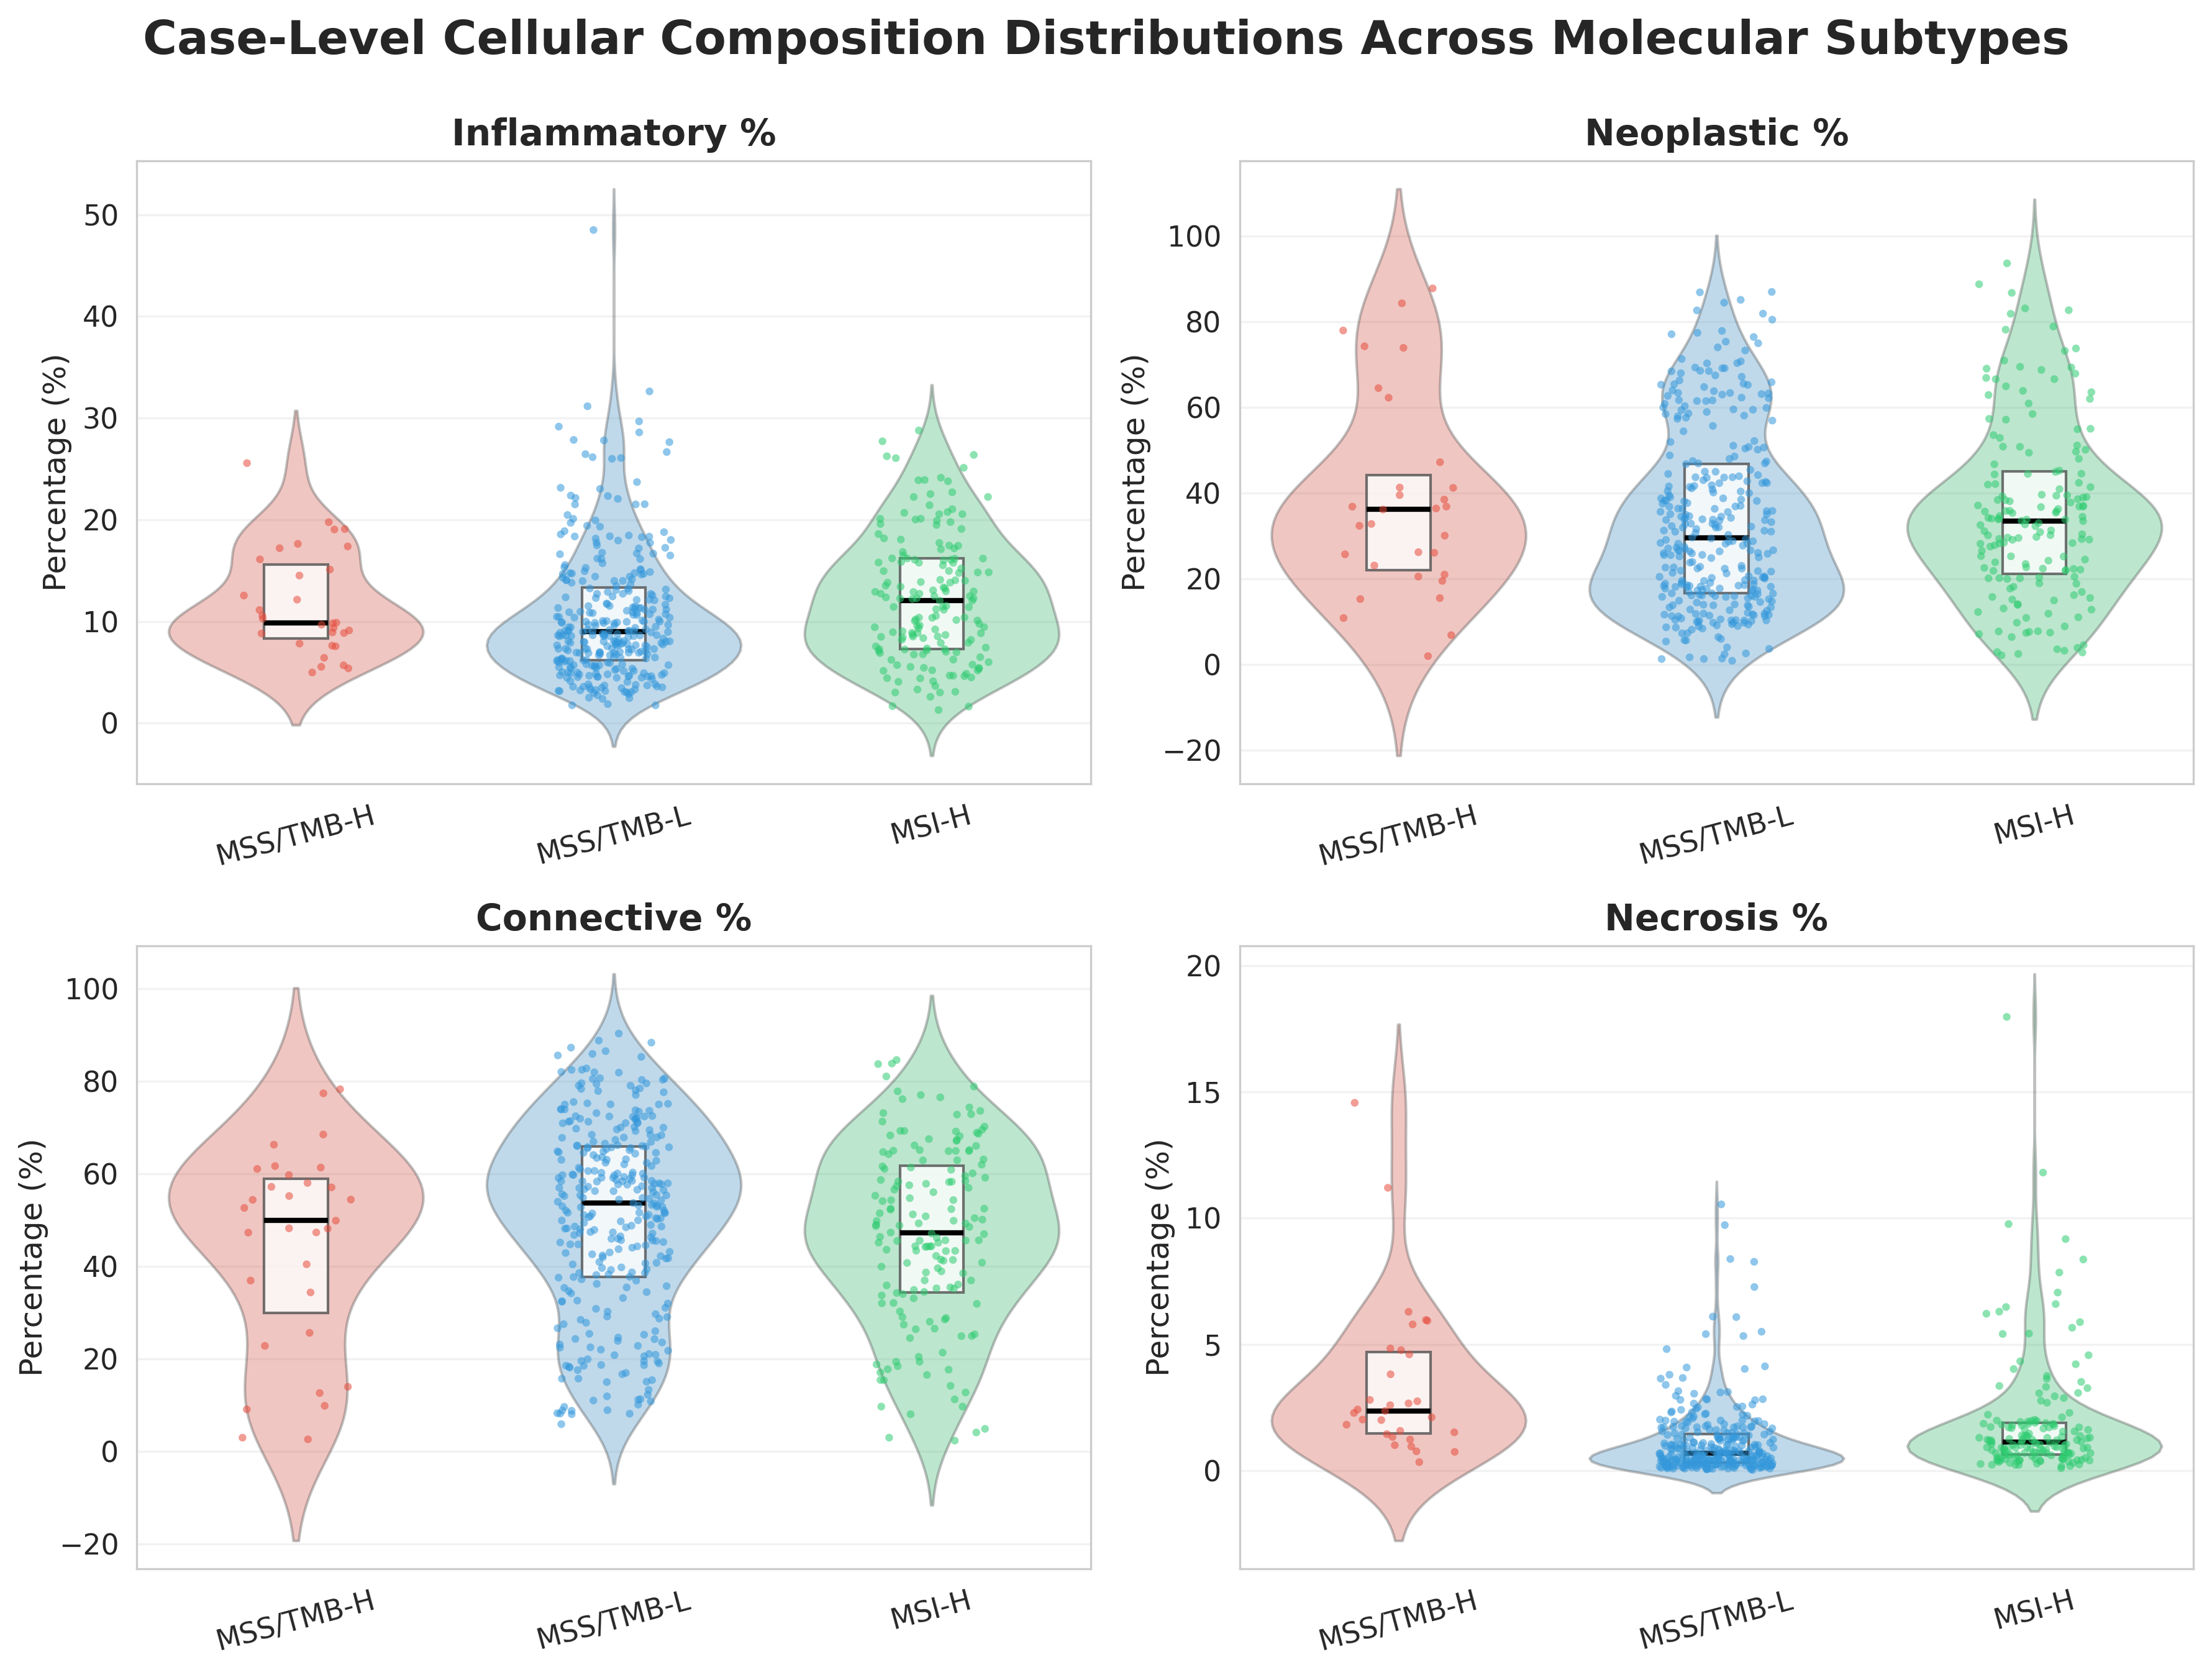

In [10]:
features = [
    ("inflammatory_pct_mean", "Inflammatory %"),
    ("neoplastic_pct_mean", "Neoplastic %"),
    ("connective_pct_mean", "Connective %"),
    ("necrosis_pct_mean", "Necrosis %"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (col, title) in zip(axes, features):

    df_clean = case_level.copy()

    # 1. Transparent violin layer
    sns.violinplot(
        data=df_clean,
        x="group",
        y=col,
        order=SUBTYPES,
        palette=GROUP_COLORS,
        inner=None,
        alpha=0.35,
        linewidth=1,
        ax=ax
    )

    # 2. Boxplot overlay
    sns.boxplot(
        data=df_clean,
        x="group",
        y=col,
        order=SUBTYPES,
        width=0.20,
        showcaps=False,
        boxprops={"facecolor": "white", "alpha": 0.8},
        showfliers=False,
        whiskerprops={"linewidth": 0},
        medianprops={"color": "black", "linewidth": 2},
        ax=ax
    )

    # 3. Stripplot of raw points
    sns.stripplot(
        data=df_clean,
        x="group",
        y=col,
        order=SUBTYPES,
        palette=GROUP_COLORS,
        size=3,
        jitter=0.18,
        alpha=0.55,
        ax=ax
    )

    # Axis styles
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Percentage (%)", fontsize=12)
    ax.tick_params(axis="x", rotation=15, labelsize=11)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle(
    "Case-Level Cellular Composition Distributions Across Molecular Subtypes",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

plt.tight_layout()
plt.savefig("images/celltype_violin_overview.png",dpi=300,  bbox_inches='tight')
plt.show()

The Descriptive Analysis revealed that MSS/TMB-H tumors occupied an intermediate position between MSS/TMB-L and MSI-H in terms of immune infiltration (median: $9.87\%$ vs $8.96\%$ vs $12.04\%$, respectively). However, MSS/TMB-H tumors showed distinct features, including markedly higher necrotic content (median: $2.36\%$ vs $0.68\%$ in MSS/TMB-L) and lower variability in immune infiltration levels across patients (SD: $5.13$ vs $6.41$), suggesting greater phenotypic consistency within this molecular subgroup.

## Normality and Variance Tests

Before performing group comparisons or regression analyses, it is essential to verify wheter the data follows a **normal (Gaussian) distribution**. The assumption of normality underlies many parametric statistical tests. 

Therefore, Shapiro-Wilk tests were conducted for each variable within each molecular group to assess wheter the data follows a normal distribution. 

The hypotheses for the Shapiro–Wilk test are:


$$
\begin{aligned}
H_0 &:~ \text{The data come from a normal distribution} \\
H_1 &:~ \text{The data do not come from a normal distribution}
\end{aligned}
$$
A p-value greater than  $\small{p > 0.05}$ indicates that the null hypothesis cannot be rejected, suggesting that the data are consistent with a normal distribution. Conversely, a p-value below  $\small{p < 0.05}$ indicates a significant deviation from normality.


#### The Focus Lies on: 
1. Whetere each metric (e.g. cell normalized, necrosis %, immune inflation) is approximately normally distributed. 

2. Wheter any variables significantly deviate from normality $\small{p < 0.05}$

3. Based on these results, whether it is appropriate to use parametric or non-parametric statistical methods for subsequent analyses.

In [11]:
normality_results = []
for metric, label in key_metrics:
    # Test normality for each group
    for group in SUBTYPES:
        data = case_level[case_level['group'] == group][metric].dropna()
        
        if len(data) >= 3:
            stat, p = shapiro(data)
            is_normal = p > 0.05
            
            normality_results.append({
                'Metric': label,
                'Group': group,
                'Test': 'Shapiro-Wilk',
                'Statistic': f"{stat:.4f}",
                'P-value': f"{p:.4f}",
                'Distribution': 'Normal' if is_normal else 'Non-normal'
            })

normality_results = pd.DataFrame(normality_results)

In [12]:
for group in SUBTYPES:
    df_group = normality_results[normality_results['Group'] == group].drop('Group', axis=1).reset_index(drop=True)
    
    display(df_group.style
            .set_caption(f"Normality Test Results - {group}")
            .set_properties(**{'text-align': 'center'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
                {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
            ]))

,Metric,Test,Statistic,P-value,Distribution
0,Total Nuclei per Case,Shapiro-Wilk,0.9207,0.0247,Non-normal
1,Mean Nuclei per Tile,Shapiro-Wilk,0.9578,0.2550,Normal
2,Mean Cell normalized,Shapiro-Wilk,0.1951,0.0000,Non-normal
3,Neoplastic %,Shapiro-Wilk,0.9233,0.0289,Non-normal
4,Inflammatory %,Shapiro-Wilk,0.9211,0.0253,Non-normal
5,Connective %,Shapiro-Wilk,0.9164,0.0190,Non-normal
6,Necrosis %,Shapiro-Wilk,0.7612,0.0000,Non-normal
7,Inflammatory Normalized,Shapiro-Wilk,0.2416,0.0000,Non-normal


,Metric,Test,Statistic,P-value,Distribution
0,Total Nuclei per Case,Shapiro-Wilk,0.9818,0.0004,Non-normal
1,Mean Nuclei per Tile,Shapiro-Wilk,0.6734,0.0000,Non-normal
2,Mean Cell normalized,Shapiro-Wilk,0.6731,0.0000,Non-normal
3,Neoplastic %,Shapiro-Wilk,0.9424,0.0000,Non-normal
4,Inflammatory %,Shapiro-Wilk,0.8776,0.0000,Non-normal
5,Connective %,Shapiro-Wilk,0.9678,0.0000,Non-normal
6,Necrosis %,Shapiro-Wilk,0.6568,0.0000,Non-normal
7,Inflammatory Normalized,Shapiro-Wilk,0.6735,0.0000,Non-normal


,Metric,Test,Statistic,P-value,Distribution
0,Total Nuclei per Case,Shapiro-Wilk,0.9772,0.0086,Non-normal
1,Mean Nuclei per Tile,Shapiro-Wilk,0.6600,0.0000,Non-normal
2,Mean Cell normalized,Shapiro-Wilk,0.6816,0.0000,Non-normal
3,Neoplastic %,Shapiro-Wilk,0.9573,0.0001,Non-normal
4,Inflammatory %,Shapiro-Wilk,0.9708,0.0016,Non-normal
5,Connective %,Shapiro-Wilk,0.9810,0.0243,Non-normal
6,Necrosis %,Shapiro-Wilk,0.6289,0.0000,Non-normal
7,Inflammatory Normalized,Shapiro-Wilk,0.6594,0.0000,Non-normal


The Shapiro-Wilk results indicated **systematic non-normality across all variables and groups $(\small{p < 0.05})$. Only one variable, *Mean Nuclei per tile* in the **TMB-H** group, was approximately normmal $(\small{p > 0.05})$. 

- Non-normality is expected in this biological context due to heterogeneity in tumor architecture and bounded data (percentages, cell counts).

- The presence of skewed and heavy-tailed distributions reflects real biological variation, not measurement error.

- Because the majority of variables significantly deviated from normality, non-parametric tests (Kruskal–Wallis and Mann–Whitney U) were used for group comparisons, as these methods do not assume normality and are robust to outliers.

In [13]:
pd.DataFrame(normality_results).to_csv(
    'statistical_tests/normality_tests.csv',
    index=False)

## Primary Statistical Tests

Following the normality assessment, most variables deviated significantly from a normal distribution. non-parametric statistical methods were used to compare the three molecular groups (TMB-H, MSS/TMB-L, and MSI-H).

The **Kruskal–Wallis test** was applied to detect overall group differences for each histopathological variable. When significant differences were observed $\small{(p < 0.05)}$, pairwise **Mann–Whitney U tests** with rank-biserial correlations $\small{(r)}$ were performed to identify which specific groups contributed to the observed differences. The rank-biserial correlation $\small{(r)}$ quantifies the magnitude and direction of the difference between two groups in a non-parametric context.

| Test               | Null Hypothesis $(H_0)$                                          | Alternative Hypothesis $(H_1)$                              |
| ------------------ | -------------------------------------------------------------- | --------------------------------------------------------- |
| **Mann–Whitney U** | The two groups come from the same distribution (medians equal) | The two groups differ in distribution (medians not equal) |
| **Kruskal–Wallis** | All groups come from the same distribution (medians equal)     | At least one group differs from the others                |


#### Effect Size: Rank-Biserial Correlation

The **rank-biserial correlation** $(r)$ quantifies the magnitude and direction of the difference between two groups in a non-parametric context. It is calculated from the Mann-Whitney U statistic as:

$$r = 1 - \frac{2U}{n_1 \times n_2}$$

where:
- $U$ = Mann-Whitney U statistic
- $n_1$ = sample size of group 1
- $n_2$ = sample size of group 2

**Interpretation:**
- $r = +1$: All values in group 1 are higher than all values in group 2 (complete separation)
- $r = 0$: Groups overlap completely (no systematic difference)
- $r = -1$: All values in group 1 are lower than all values in group 2 (complete separation)

**Effect Size Guidelines:**
- $|r| < 0.3$: **Small effect** (slight difference between groups)
- $0.3 \leq |r| < 0.5$: **Medium effect** (moderate group separation)
- $|r| \geq 0.5$: **Large effect** (substantial group separation)

##### Examples:
- $r = +0.16$: Small positive effect - group 1 tends to have slightly higher values than group 2
- $r = +0.67$: Large positive effect - group 1 has substantially higher values than group 2
- $r = -0.42$: Medium negative effect - group 1 has moderately lower values than group 2

#### Objective
The scope is to determine whether histopathological characteristics such as cellularity, tissue composition, and inflammatory or necrotic content differed systematically between molecular subtypes. Detecting significant differences would indicate biologically meaningful morphological variation across groups.


In [14]:
all_pvalues = []
all_tests = []
test_results = []

for metric, label in key_metrics:
    # Prepare data for the three groups
    tmb_h = case_level[case_level['group'] == 'MSS/TMB-H'][metric]
    mss = case_level[case_level['group'] == 'MSS/TMB-L'][metric]
    msi_h = case_level[case_level['group'] == 'MSI-H'][metric]
    
    # Kruskal-Wallis (non-parametric)
    h_stat, p_kw = kruskal(tmb_h, mss, msi_h)
    
    sig_level = '***' if p_kw < 0.001 else '**' if p_kw < 0.01 else '*' if p_kw < 0.05 else 'not significant'
    
    test_results.append({
        'Metric': label,
        'Test': 'Kruskal-Wallis (3-group)',
        'Statistic': f"{h_stat:.3f}",
        'P-value': f"{p_kw:.4f}",
        'Significance': sig_level
    })
    
    if p_kw < 0.05:
        comparisons = [
            ('MSS/TMB-H', 'MSS/TMB-L', tmb_h, mss),
            ('MSS/TMB-H', 'MSI-H', tmb_h, msi_h),
            ('MSS/TMB-L', 'MSI-H', mss, msi_h)
        ]
        
        for group1, group2, data1, data2 in comparisons:
            u_stat, p_mw = mannwhitneyu(data1, data2, alternative='two-sided')
            
            r = 1 - (2*u_stat) / (len(data1) * len(data2))
            
            if abs(r) < 0.3:
                magnitude = "small"
            elif abs(r) < 0.5:
                magnitude = "medium"
            else:
                magnitude = "large"
            
            sig_level = '***' if p_mw < 0.001 else '**' if p_mw < 0.01 else '*' if p_mw < 0.05 else 'not significant'
            
            all_pvalues.append(p_mw)
            all_tests.append(f"{label}: {group1} vs {group2}")
            
            test_results.append({
                'Metric': label,
                'Test': f'{group1} vs {group2}',
                'Statistic': f"{u_stat:.1f}",
                'P-value': f"{p_mw:.4f}",
                'Effect Size (r)': f"{r:+.3f}",
                'Magnitude': magnitude,
                'Significance': sig_level
            })

test_results_df = pd.DataFrame(test_results)
pd.DataFrame(test_results_df).to_csv(
    'statistical_tests/kruskal_mann_whitney_results.csv',
    index=False)

In [15]:
kw_results = test_results_df[test_results_df['Test'] == 'Kruskal-Wallis (3-group)'].reset_index(drop=True)
display(kw_results.style
        .set_caption("Kruskal-Wallis Test Results (3-Group Comparison)")
        .set_properties(**{'text-align': 'center'})
        .set_table_styles([
            {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
            {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
        ]))


,Metric,Test,Statistic,P-value,Significance,Effect Size (r),Magnitude
0,Total Nuclei per Case,Kruskal-Wallis (3-group),1.083,0.5820,not significant,nan,nan
1,Mean Nuclei per Tile,Kruskal-Wallis (3-group),8.166,0.0169,*,nan,nan
2,Mean Cell normalized,Kruskal-Wallis (3-group),9.653,0.0080,**,nan,nan
3,Neoplastic %,Kruskal-Wallis (3-group),2.442,0.2949,not significant,nan,nan
4,Inflammatory %,Kruskal-Wallis (3-group),13.444,0.0012,**,nan,nan
5,Connective %,Kruskal-Wallis (3-group),6.187,0.0453,*,nan,nan
6,Necrosis %,Kruskal-Wallis (3-group),57.995,0.0000,***,nan,nan
7,Inflammatory Normalized,Kruskal-Wallis (3-group),9.070,0.0107,*,nan,nan


The statistical analysis revealed significant differences in the tumor microenvironment composition across molecular subtypes, particularly within the non-neoplastic compartments. The strongest divergence was observed in **Necrosis %** ($p < 0.001$) and **Inflammatory %** ($p = 0.0012$), confirming that levels of tissue death and immune infiltration are key differentiating features between these groups. Significant variation was also found in **Connective %** ($p = 0.045$) and overall cellular density (**Mean Nuclei per Tile**, $p = 0.017$), whereas **Neoplastic %** did not differ significantly ($p = 0.295$), suggesting that tumor purity remains relatively comparable across subtypes despite the distinct stromal and immune landscapes.

In [16]:
pairwise_results = test_results_df[test_results_df['Test'] != 'Kruskal-Wallis (3-group)'].reset_index(drop=True)
if len(pairwise_results) > 0:
    display(pairwise_results.style
            .set_caption("Post-hoc Pairwise Comparisons (Mann-Whitney U Tests)")
            .set_properties(**{'text-align': 'center'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'center'), ('font-weight', 'bold')]},
                {'selector': 'caption', 'props': [('font-size', '16px'), ('font-weight', 'bold')]}
            ]))

,Metric,Test,Statistic,P-value,Significance,Effect Size (r),Magnitude
0,Mean Nuclei per Tile,MSS/TMB-H vs MSS/TMB-L,5132.0,0.7505,not significant,-0.035,small
1,Mean Nuclei per Tile,MSS/TMB-H vs MSI-H,2272.0,0.3754,not significant,+0.101,small
2,Mean Nuclei per Tile,MSS/TMB-L vs MSI-H,21899.0,0.0039,**,+0.160,small
3,Mean Cell normalized,MSS/TMB-H vs MSS/TMB-L,5342.0,0.4794,not significant,-0.077,small
4,Mean Cell normalized,MSS/TMB-H vs MSI-H,2311.0,0.4531,not significant,+0.085,small
5,Mean Cell normalized,MSS/TMB-L vs MSI-H,21567.0,0.0019,**,+0.173,small
6,Inflammatory %,MSS/TMB-H vs MSS/TMB-L,5885.0,0.0866,not significant,-0.186,small
7,Inflammatory %,MSS/TMB-H vs MSI-H,2433.0,0.7455,not significant,+0.037,small
8,Inflammatory %,MSS/TMB-L vs MSI-H,21026.0,0.0005,***,+0.194,small
9,Connective %,MSS/TMB-H vs MSS/TMB-L,4152.0,0.1344,not significant,+0.163,small


Although the global Kruskal–Wallis test indicated significant heterogeneity in inflammatory markers across the cohort ($p = 0.0012$), post-hoc analysis revealed that the **MSS/TMB-H group did not differ significantly** from the other subtypes. Pairwise Mann–Whitney tests involving MSS/TMB-H yielded **non-significant results** $\small{(p > 0.05)}$ with small effect sizes $\small{(r < 0.2)}$. This suggests that **MSS/TMB-H tumors exhibit an intermediate inflammatory profile**, lacking the pronounced immune infiltration characteristic of MSI-H tumors but not as low as in MSS/TMB-L cases. Overall, the data indicate that the inflammatory microenvironment in MSS/TMB-H tumors is relatively moderate and statistically indistinguishable from the other groups."

## Visualization 

In this section, we visualize the cellular composition across molecular subtypes to contextualize the statistical findings. We utilize violin plots with overlaid significance markers to highlight key differences in tissue architecture, followed by a correlation analysis to explore potential relationships between distinct cellular compartments.

In [17]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

df_clean = remove_outliers_iqr(case_level, metric)

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MSS/TMB-H vs. MSS/TMB-L: Mann-Whitney-Wilcoxon test two-sided, P_val:7.487e-01 U_stat=4.644e+03


MSS/TMB-L vs. MSI-H: Mann-Whitney-Wilcoxon test two-sided, P_val:5.572e-01 U_stat=2.429e+04
MSS/TMB-H vs. MSI-H: Mann-Whitney-Wilcoxon test two-sided, P_val:9.862e-01 U_stat=2.193e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MSS/TMB-H vs. MSS/TMB-L: Mann-Whitney-Wilcoxon test two-sided, P_val:2.722e-02 U_stat=5.885e+03
MSS/TMB-L vs. MSI-H: Mann-Whitney-Wilcoxon test two-sided, P_val:1.005e-05 U_stat=1.877e+04
MSS/TMB-H vs. MSI-H: Mann-Whitney-Wilcoxon test two-sided, P_val:7.455e-01 U_stat=2.433e+03
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

MSS/TMB-H vs. MSS/TMB-L: Mann-Whitney-Wilcoxon test two-sided, P_val:1.344e-01 U_stat=4.152e+03
MSS/TMB-L vs. MSI-H: Mann-Whitney-Wilcoxon test two-side

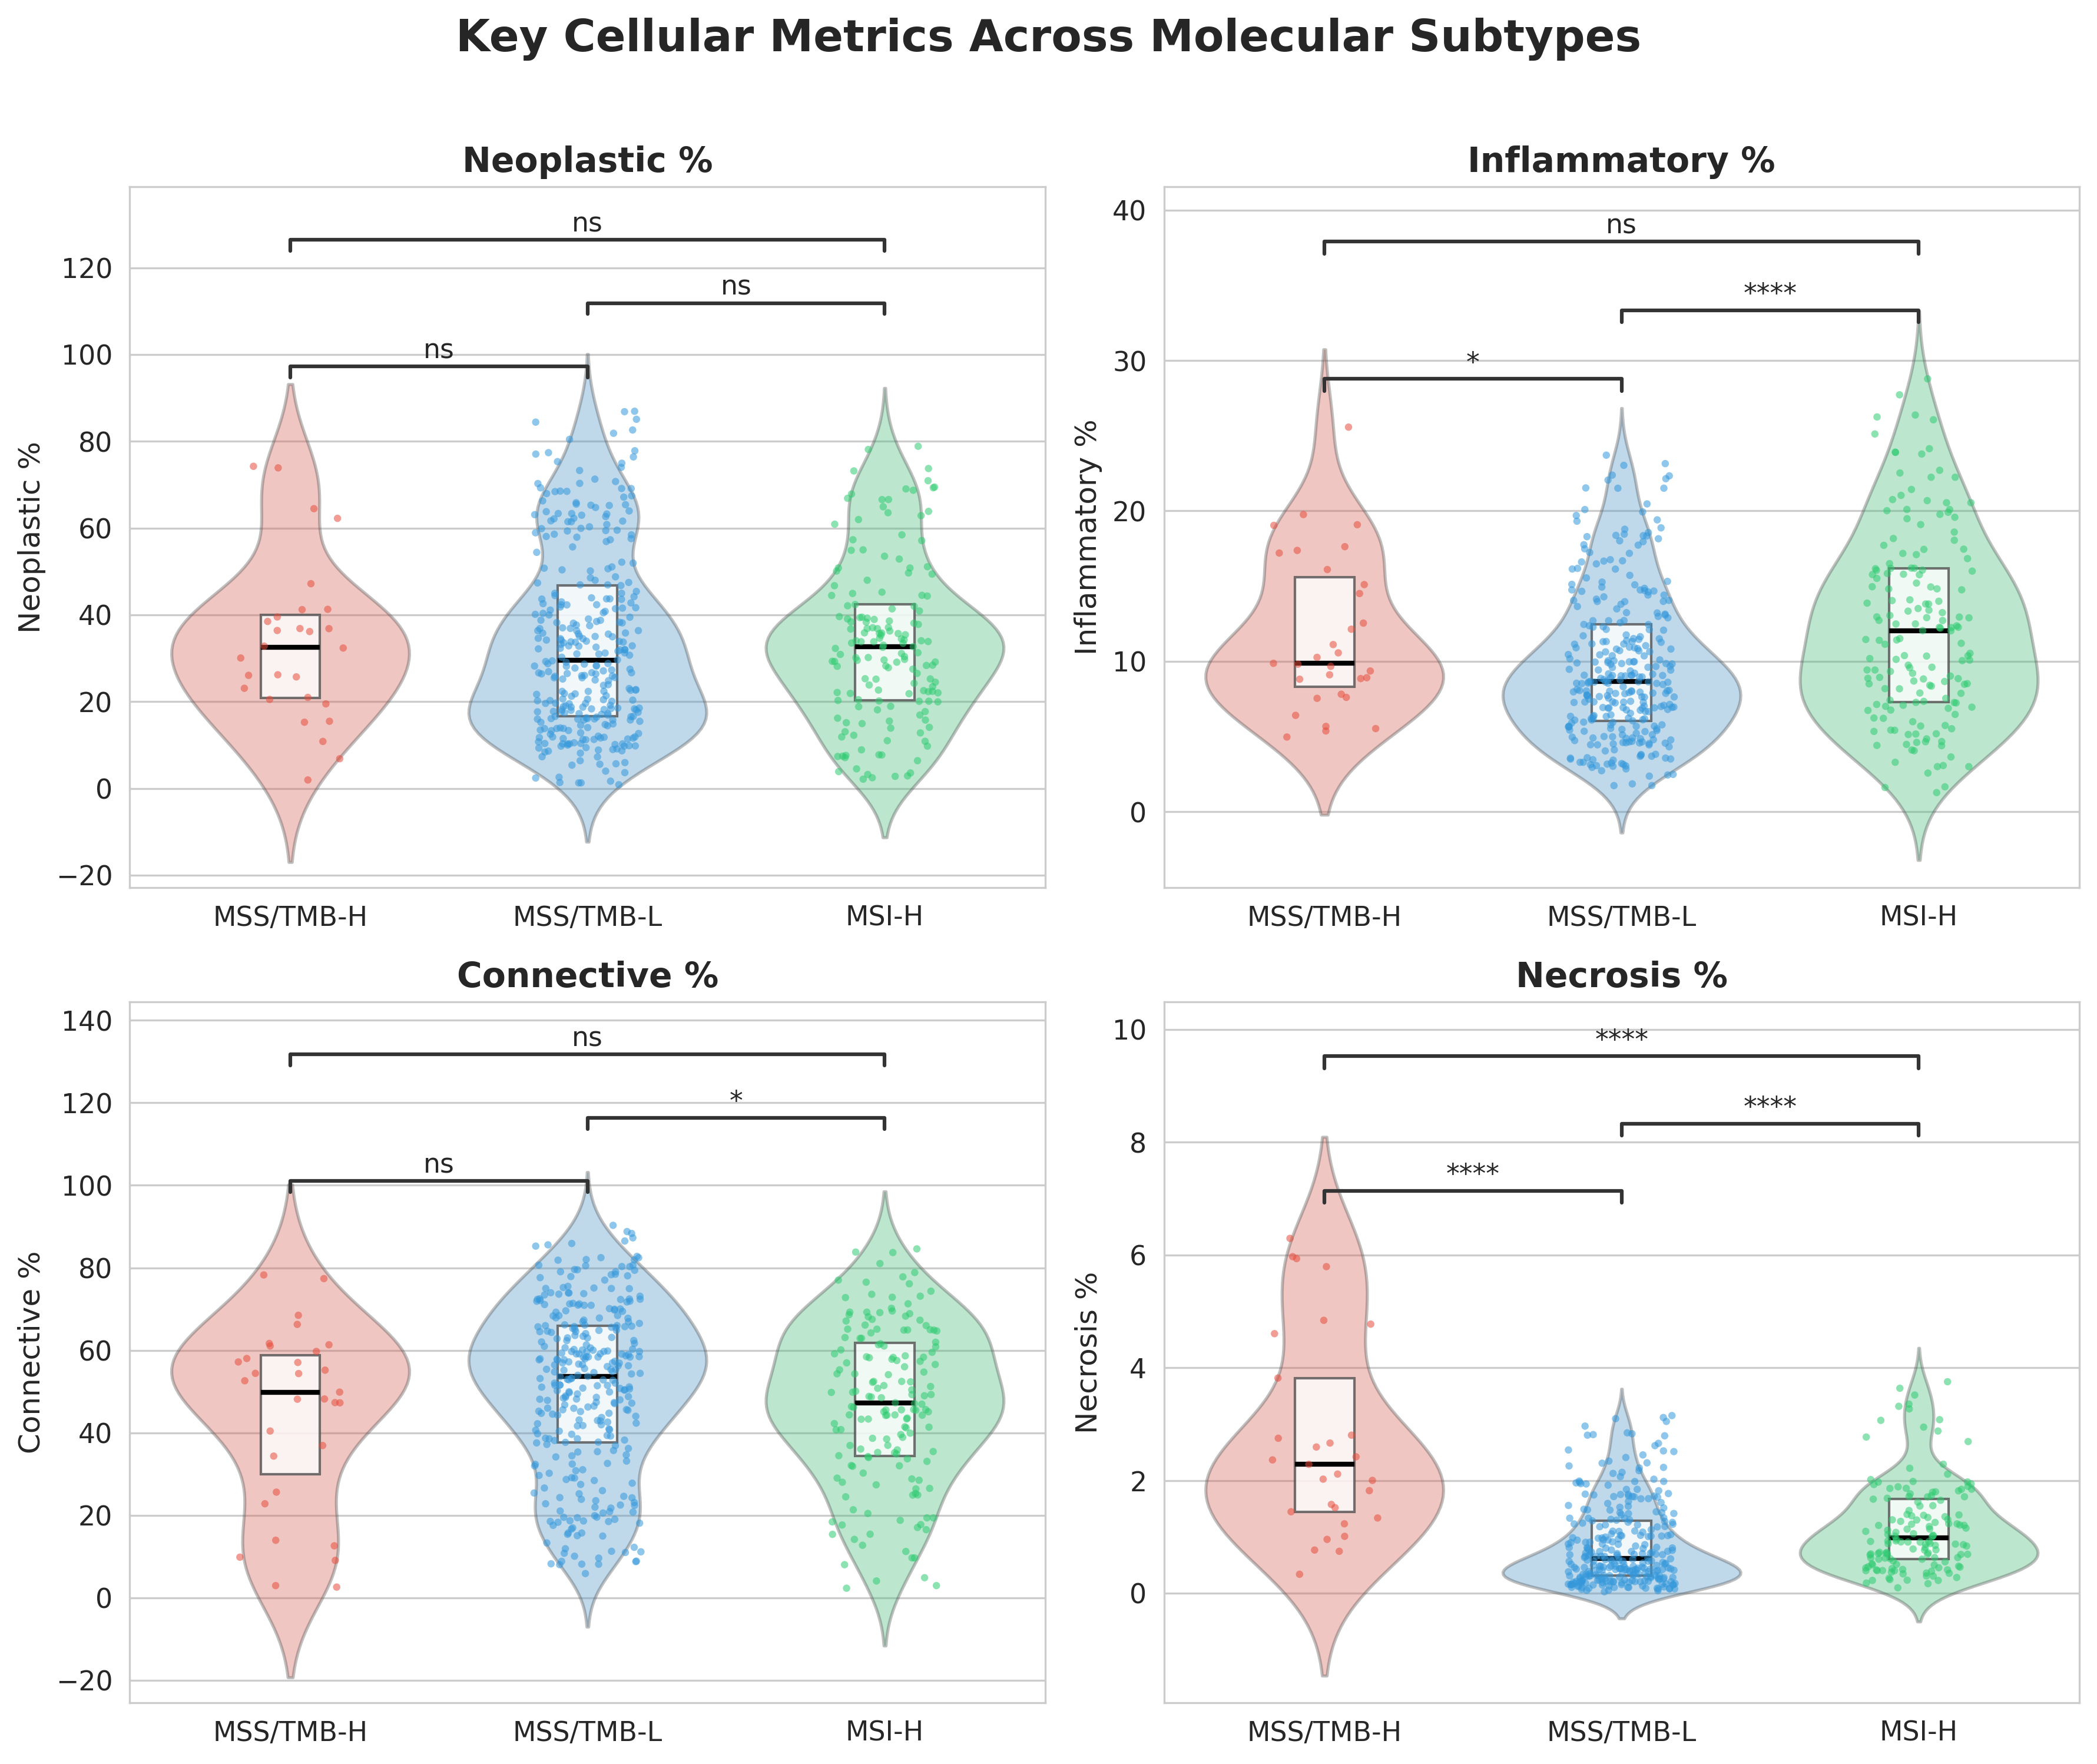

In [18]:
metrics_to_plot = [
    ('neoplastic_pct_mean', 'Neoplastic %'),
    ('inflammatory_pct_mean', 'Inflammatory %'),
    ('connective_pct_mean', 'Connective %'),
    ('necrosis_pct_mean', 'Necrosis %'),
]

# Number of metrics
num_metrics = len(metrics_to_plot)

# Grid shape
ncols = 2
nrows = (num_metrics + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = axes.flatten()

comparisons = [
    ("MSS/TMB-H", "MSS/TMB-L"),
    ("MSS/TMB-H", "MSI-H"),
    ("MSS/TMB-L", "MSI-H")
]

for ax, (metric, label) in zip(axes, metrics_to_plot):

    # Outlier removal per your original code
    df_clean = (
        case_level
        .groupby('group')
        .apply(lambda x: remove_outliers_iqr(x, metric))
        .reset_index(drop=True)
    )

    #  Violin 
    sns.violinplot(
        data=df_clean,
        x='group',
        y=metric,
        order=SUBTYPES,
        palette=GROUP_COLORS,
        inner=None,
        alpha=0.35,
        ax=ax
    )

    #  Boxplot 
    sns.boxplot(
        data=df_clean,
        x='group',
        y=metric,
        order=SUBTYPES,
        width=0.2,
        showcaps=False,
        boxprops={'facecolor': 'white', 'alpha': 0.8},
        showfliers=False,
        whiskerprops={'linewidth': 0},
        medianprops={'color': 'black', 'linewidth': 2},
        ax=ax
    )

    #  Stripplot 
    sns.stripplot(
        data=df_clean,
        x='group',
        y=metric,
        order=SUBTYPES,
        palette=GROUP_COLORS,
        size=3,
        jitter=0.18,
        alpha=0.55,
        ax=ax
    )

    ax.set_title(label, fontsize=14, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel(label)

    #  Significance Annotation 
    annot = Annotator(
        ax,
        comparisons,
        data=df_clean,
        x='group',
        y=metric,
        order=SUBTYPES
    )
    annot.configure(
        test='Mann-Whitney',
        text_format='star',
        loc='inside'
    )
    annot.apply_and_annotate()

# Turn off empty axes 
for i in range(num_metrics, len(axes)):
    axes[i].axis("off")

fig.suptitle(
    "Key Cellular Metrics Across Molecular Subtypes",
    fontsize=18,
    fontweight="bold",
    y=0.995
)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("images/all_metrics_violin_significance.png", dpi=300)
plt.show()


## Correlation Analysis

In [19]:
corr_features_comprehensive = [
    'neoplastic_pct_mean',
    'connective_pct_mean',
    'necrosis_pct_mean',
    'inflammatory_pct_mean',
    'inflammatory_normalized_mean',
    'neoplastic_pct_std',
    'inflammatory_pct_std',
    'total_nuclei_mean',
    'n_tiles',
]
feature_labels = [
    'Neoplastic %',
    'Connective %', 
    'Necrosis %',
    'Inflammatory %',
    'Inflammatory Density',
    'Tumor Heterogeneity',
    'Immune Heterogeneity',
    'Total Cellularity',
    'WSI Coverage',
]


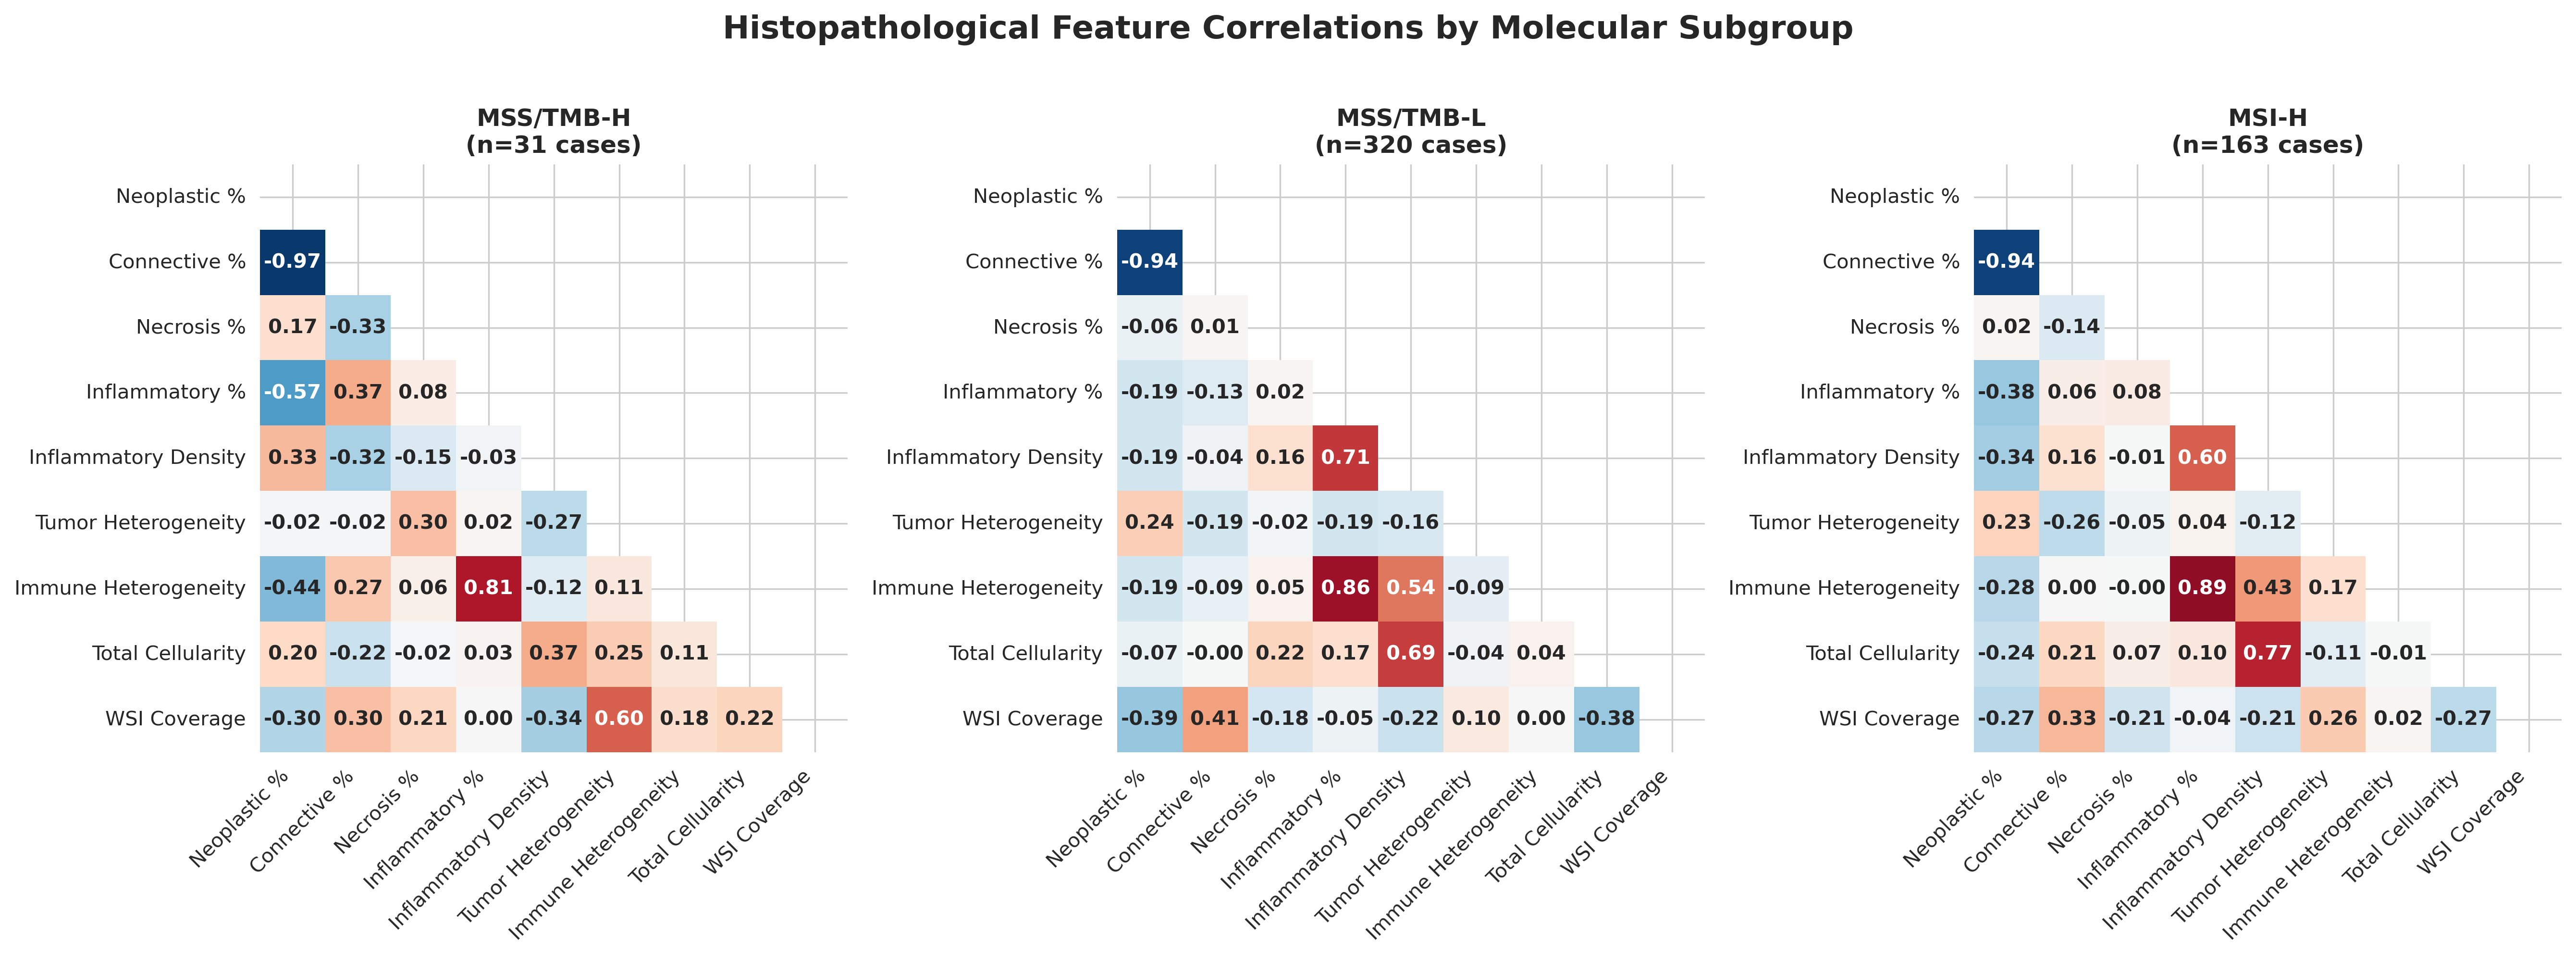

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(18, 8))

for idx, (ax, group) in enumerate(zip(axes, SUBTYPES)):
    data = case_level[case_level['group'] == group][corr_features_comprehensive]
    corr = data.corr()
    
    # Upper triangle mask
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Heatmap without colorbar
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
                cmap='RdBu_r', center=0, square=True, ax=ax, 
                vmin=-1, vmax=1, 
                cbar=False, 
                annot_kws={'size': 10, 'weight': 'bold'}, 
                xticklabels=feature_labels, yticklabels=feature_labels)
    
    ax.set_title(f'{group}\n(n={len(data)} cases)', fontweight='bold', fontsize=12)
    
    ax.set_xticks(np.arange(len(feature_labels)) + 0.5)
    ax.set_yticks(np.arange(len(feature_labels)) + 0.5)
    ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=10)
    ax.set_yticklabels(feature_labels, rotation=0, fontsize=10)

plt.suptitle('Histopathological Feature Correlations by Molecular Subgroup',
             fontsize=16, fontweight='bold', y=0.88)
plt.tight_layout()
plt.savefig('images/correlation_matrices_optimized.png', dpi=300, bbox_inches='tight')
# plt.show()

#### The plot below has only been used for publication purposes

In [21]:
# # Create three separate plots
# for group in SUBTYPES:
#     fig, ax = plt.subplots(figsize=(10, 7))
    
#     data = case_level[case_level['group'] == group][corr_features_comprehensive]
#     corr = data.corr()
    
#     mask = np.triu(np.ones_like(corr, dtype=bool))
    
#     sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', 
#                 cmap='RdBu_r', center=0, square=True, ax=ax, 
#                 vmin=-1, vmax=1, cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
#                 xticklabels=feature_labels, yticklabels=feature_labels,
#                 cbar=False, 
#                 annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    
#     ax.set_title(f'Histopathological Feature Correlations - {group}\n(n={len(data)} cases)', 
#                  fontweight='bold', fontsize=14, pad=15,  x=0.35)
#     ax.set_xticklabels(feature_labels, rotation=45, ha='right', fontsize=11)
#     ax.set_yticklabels(feature_labels, rotation=0, fontsize=11)
    
#     plt.tight_layout()
    
#     # Save each plot with a unique filename
#     filename = group.replace('/', '_').replace('-', '_')
#     plt.savefig(f'images/correlation_matrix_{filename}.png', dpi=300, bbox_inches='tight')
#     plt.show()
#     plt.close() 

# Discussion 

The statistical analysis identifies **necrosis levels** and **immune infiltration** as the primary drivers of histological variation between molecular subtypes, with necrosis exhibiting the strongest discriminatory power ($r > 0.6$). While **MSI-H** tumors are defined by a highly immunogenic profile, the **MSS/TMB-H** group emerges as a unique intermediate entity characterized by elevated necrosis and greater phenotypic consistency compared to the heterogeneous **MSS/TMB-L** cohort. Notably, these profound microenvironmental differences exist despite a lack of significant variation in overall neoplastic content ($p = 0.29$), underscoring that the major histological distinctions lie in the stromal and immune compartments rather than tumor purity itself.